# Reusable Template: Regression Modeling Workflow

A parameterized template for running the full MLR → feature selection → shrinkage → dimension-reduction
workflow on **your own dataset**. Edit only the `CONFIG` cell below, then run the notebook top to bottom.

This template is demonstrated on `Hitters.csv` (predicting `Salary`), but every function is written generically
in terms of `CONFIG` — swap in your own CSV, target column, and categorical columns and re-run.

**What this template does for you:**
1. Loads your CSV, drops rows with missing target, one-hot encodes categorical columns.
2. Splits into train/test and scales features (leakage-free: scaler fit on training data only).
3. Fits OLS with statsmodels and reports VIF-based multicollinearity diagnostics.
4. Runs RFECV for performance-based feature selection.
5. Tunes Ridge / LASSO / Elastic Net via cross-validation.
6. Runs PCR and PLS with cross-validated component selection.
7. Produces a single comparison table + bar chart across all methods.

**What you still need to do yourself:** look at the diagnostic plots and decide whether assumptions are
reasonably met, pick a final model based on your own priorities (interpretability vs. raw performance), and
sanity-check the results against domain knowledge. No template can do that judgment for you.


## CONFIG — edit this cell for your own dataset

In [1]:
CONFIG = {
    "csv_path": "Hitters.csv",       # path to your CSV file
    "target_col": "Salary",           # column you want to predict
    "categorical_cols": ["League", "Division", "NewLeague"],   # columns to one-hot encode (or [] if none)
    "drop_cols": [],                  # any other columns to exclude entirely (e.g. IDs, free text)
    "test_size": 0.2,
    "random_state": 42,
    "vif_threshold": 5.0,             # VIF cutoff for multicollinearity reduction
    "cv_folds": 10,                   # cross-validation folds for component/hyperparameter selection
    "max_pcr_pls_components": 15,     # cap on components to search over for PCR/PLS
}


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

np.random.seed(CONFIG["random_state"])

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


## Step 1 — Load & prepare data

In [3]:
def load_and_prepare(config):
    df = pd.read_csv(config["csv_path"])
    df = df.dropna(subset=[config["target_col"]])   # require a known target
    df = df.drop(columns=config["drop_cols"], errors="ignore")

    y = df[config["target_col"]]
    feature_df = df.drop(columns=[config["target_col"]])

    cat_cols = [c for c in config["categorical_cols"] if c in feature_df.columns]
    num_df = feature_df.drop(columns=cat_cols).apply(pd.to_numeric, errors="coerce")
    num_df = num_df.dropna(axis=1, how="all")   # drop any columns that were entirely non-numeric junk

    if cat_cols:
        dummies = pd.get_dummies(feature_df[cat_cols], drop_first=True)
        X = pd.concat([num_df, dummies], axis=1)
    else:
        X = num_df

    # If any numeric columns still have missing values, impute with the column median (simple default).
    if X.isna().any().any():
        X = X.fillna(X.median(numeric_only=True))

    return X, y

X_raw, y = load_and_prepare(CONFIG)
print("Feature matrix shape:", X_raw.shape)
X_raw.head()


Feature matrix shape: (263, 19)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,False,True,False


## Step 2 — Train/test split & scaling (leakage-free)

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=CONFIG["test_size"], random_state=CONFIG["random_state"]
)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

feature_names = X_raw.columns.tolist()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (210, 19), Test: (53, 19)


## Step 3 — OLS baseline + VIF diagnostics

In [5]:
def reduce_by_vif(X_df, threshold=5.0, protect=("const",)):
    X_work = X_df.copy()
    log = []
    while True:
        vifs = np.array([vif(X_work.values, i) for i in range(X_work.shape[1])])
        s = pd.Series(vifs, index=X_work.columns)
        droppable = s.drop(labels=[c for c in protect if c in s.index])
        if len(droppable) == 0 or droppable.max() < threshold:
            break
        worst = droppable.idxmax()
        log.append((worst, droppable.max()))
        X_work = X_work.drop(columns=[worst])
    return X_work, s, log

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_train_df.insert(0, "const", 1.0)

X_vif_reduced, final_vifs, vif_log = reduce_by_vif(X_train_df, threshold=CONFIG["vif_threshold"])
print("Dropped for high VIF:", vif_log)

ols_fit = sm.OLS(y_train.values, X_vif_reduced.values).fit()
ols_summary_df = pd.DataFrame({
    "coef": ols_fit.params, "p_value": ols_fit.pvalues
}, index=X_vif_reduced.columns)
print(f"R-squared: {ols_fit.rsquared:.3f}   Adj. R-squared: {ols_fit.rsquared_adj:.3f}")
ols_summary_df


Dropped for high VIF: [('CHits', np.float64(550.2211474794595)), ('CAtBat', np.float64(132.94941665887853)), ('CRBI', np.float64(49.29761365171538)), ('Hits', np.float64(19.74930068092105)), ('CRuns', np.float64(17.943574607587028)), ('AtBat', np.float64(9.757477057881534)), ('CWalks', np.float64(8.102647255232714)), ('RBI', np.float64(6.3926175659801165))]
R-squared: 0.512   Adj. R-squared: 0.484


,coef,p_value
const,543.664624,1.546306e-60
HmRun,-23.246192,5.290211e-01
Runs,151.503761,2.058231e-04
Walks,18.119050,5.994366e-01
Years,103.101380,5.810063e-03
CHmRun,133.837310,2.483536e-03
PutOuts,96.722934,1.158049e-04
Assists,22.826059,4.857711e-01
Errors,-13.143282,6.719992e-01
League_N,39.331931,3.838740e-01


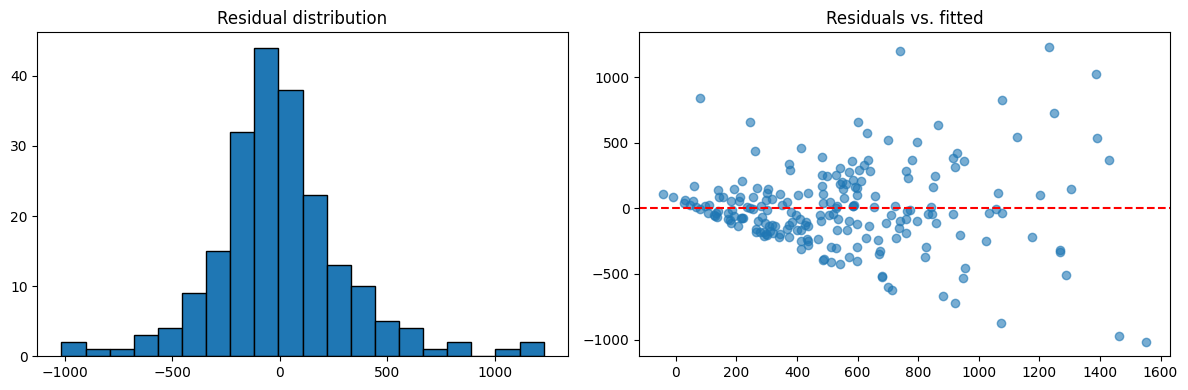

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ols_fit.resid, bins=20, edgecolor="k")
axes[0].set_title("Residual distribution")
axes[1].scatter(ols_fit.predict(X_vif_reduced.values), ols_fit.resid, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs. fitted")
plt.tight_layout()
plt.show()


## Step 4 — Performance-based feature selection (RFECV)

RFECV selected 11 of 19 features:
['AtBat', 'Hits', 'Runs', 'Walks', 'CAtBat', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'League_N', 'Division_W']


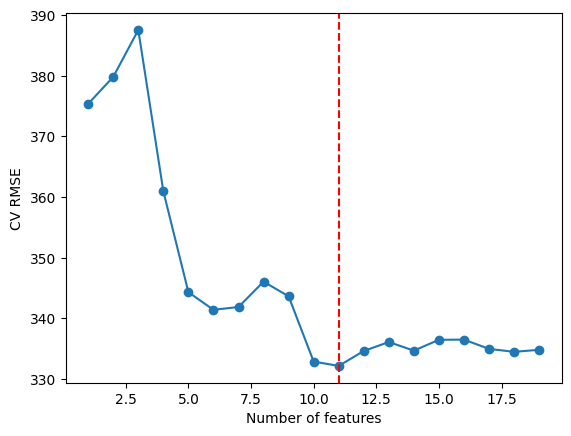

In [7]:
rfecv = RFECV(
    estimator=LinearRegression(), step=1, cv=CONFIG["cv_folds"],
    scoring="neg_root_mean_squared_error", min_features_to_select=1
)
rfecv.fit(X_train, y_train)
selected_features = [f for f, keep in zip(feature_names, rfecv.support_) if keep]
print(f"RFECV selected {rfecv.n_features_} of {len(feature_names)} features:")
print(selected_features)

plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
          -rfecv.cv_results_['mean_test_score'], '-o')
plt.axvline(rfecv.n_features_, color='red', linestyle='--')
plt.xlabel('Number of features'); plt.ylabel('CV RMSE')
plt.show()


## Step 5 — Shrinkage: Ridge / LASSO / Elastic Net (cross-validated)

In [8]:
def fit_shrinkage_models(X_tr, y_tr, cv_folds):
    alphas = np.logspace(-3, 3, 100)
    models = {}
    models["Ridge"] = RidgeCV(alphas=alphas, cv=cv_folds).fit(X_tr, y_tr)
    models["LASSO"] = LassoCV(alphas=alphas, cv=cv_folds, max_iter=20000).fit(X_tr, y_tr)
    models["ElasticNet"] = ElasticNetCV(
        alphas=alphas, l1_ratio=[.1, .3, .5, .7, .9, .95, .99, 1],
        cv=cv_folds, max_iter=20000
    ).fit(X_tr, y_tr)
    return models

shrinkage_models = fit_shrinkage_models(X_train, y_train, CONFIG["cv_folds"])
for name, m in shrinkage_models.items():
    alpha_info = getattr(m, "alpha_", None)
    l1_info = getattr(m, "l1_ratio_", None)
    print(f"{name}: alpha={alpha_info}" + (f", l1_ratio={l1_info}" if l1_info is not None else ""))


Ridge: alpha=247.7076355991714
LASSO: alpha=1.629750834620645
ElasticNet: alpha=0.6135907273413176, l1_ratio=0.1


## Step 6 — Dimension reduction: PCR and PLS (leakage-free, CV-selected components)

In [9]:
def fit_pcr(X_tr, y_tr, X_te, cv_folds, max_components=None):
    pca = PCA()
    X_pc_tr = pca.fit_transform(X_tr)
    max_components = max_components or X_pc_tr.shape[1]
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=CONFIG["random_state"])
    scores = []
    for k in range(1, min(max_components, X_pc_tr.shape[1]) + 1):
        s = -cross_val_score(LinearRegression(), X_pc_tr[:, :k], y_tr,
                              cv=cv, scoring="neg_root_mean_squared_error").mean()
        scores.append(s)
    best_k = int(np.argmin(scores)) + 1
    model = LinearRegression().fit(X_pc_tr[:, :best_k], y_tr)
    X_pc_te = pca.transform(X_te)[:, :best_k]
    return model, pca, best_k, X_pc_tr[:, :best_k], X_pc_te, scores

def fit_pls(X_tr, y_tr, cv_folds, max_components):
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=CONFIG["random_state"])
    scores = []
    max_components = min(max_components, X_tr.shape[1])
    for k in range(1, max_components + 1):
        s = -cross_val_score(PLSRegression(n_components=k), X_tr, y_tr,
                              cv=cv, scoring="neg_root_mean_squared_error").mean()
        scores.append(s)
    best_k = int(np.argmin(scores)) + 1
    model = PLSRegression(n_components=best_k).fit(X_tr, y_tr)
    return model, best_k, scores

pcr_model, pcr_pca, pcr_k, Xpc_train, Xpc_test, pcr_scores = fit_pcr(
    X_train, y_train, X_test, CONFIG["cv_folds"], CONFIG["max_pcr_pls_components"]
)
pls_model, pls_k, pls_scores = fit_pls(
    X_train, y_train, CONFIG["cv_folds"], CONFIG["max_pcr_pls_components"]
)
print(f"PCR chose {pcr_k} components; PLS chose {pls_k} components.")


PCR chose 6 components; PLS chose 1 components.


## Step 7 — Final comparison across all methods

In [10]:
results = []
results.append(("OLS (all features)", *[
    rmse(y_train, LinearRegression().fit(X_train, y_train).predict(X_train)),
    rmse(y_test, LinearRegression().fit(X_train, y_train).predict(X_test)),
]))
for name, m in shrinkage_models.items():
    results.append((name, rmse(y_train, m.predict(X_train)), rmse(y_test, m.predict(X_test))))
results.append(("PCR", rmse(y_train, pcr_model.predict(Xpc_train)), rmse(y_test, pcr_model.predict(Xpc_test))))
results.append(("PLS", rmse(y_train, pls_model.predict(X_train)), rmse(y_test, pls_model.predict(X_test))))

df_results = pd.DataFrame(results, columns=["Model", "Train RMSE", "Test RMSE"]).set_index("Model")
df_results["Overfit gap"] = df_results["Test RMSE"] - df_results["Train RMSE"]
df_results = df_results.sort_values("Test RMSE")
df_results


,Train RMSE,Test RMSE,Overfit gap
Model,,,
OLS (all features),291.828813,358.168041,66.339228
LASSO,294.929579,358.253114,63.323535
Ridge,318.964035,382.623351,63.659316
ElasticNet,312.893453,382.950527,70.057074
PCR,313.919174,388.532397,74.613223
PLS,324.723400,396.569571,71.846170


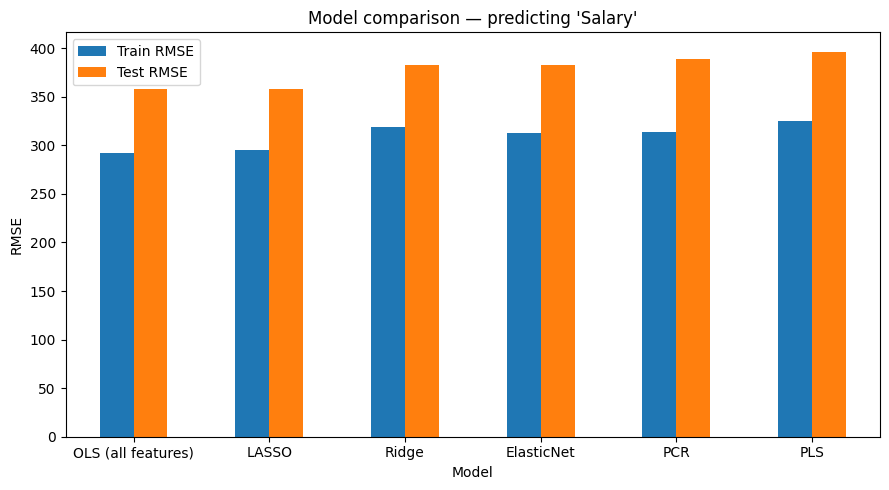

Best model by test RMSE: OLS (all features)


In [11]:
df_results[["Train RMSE", "Test RMSE"]].plot(kind="bar", figsize=(9, 5))
plt.ylabel("RMSE")
plt.title(f"Model comparison — predicting '{CONFIG['target_col']}'")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Best model by test RMSE:", df_results.index[0])


## Notes for adapting this template

- **Classification instead of regression?** Swap `LinearRegression`/`RidgeCV`/etc. for `LogisticRegression`,
  swap RMSE for accuracy/AUC, and swap `PLSRegression` for `PLSRegression` still works but you'd typically use
  `PLSCanonical`/`PLSDA`-style wrappers or just treat it as regression on a 0/1 target for a rough signal.
- **Very wide data (p >> n)?** Increase `max_pcr_pls_components`, and consider raising `n_informative`-style
  regularization strength ranges (widen the `alphas` grid) since sklearn's default range may not reach far enough.
- **Time-ordered data?** Do NOT use a random `train_test_split`; use a chronological split instead, and consider
  `TimeSeriesSplit` in place of `KFold` for cross-validation.
- **Extreme outliers in the target?** Consider a log-transform of `y` before modeling and back-transforming
  predictions, especially for skewed targets like salary or price.
- **Many categorical columns with high cardinality?** One-hot encoding as done here will blow up the feature
  count; consider target encoding or grouping rare categories first.
